In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Food_Nutrition_Dataset_v2.xlsx to Food_Nutrition_Dataset_v2.xlsx


In [21]:
df = pd.read_excel('Food_Nutrition_Dataset_v2.xlsx')

print(df.head())
print(df.shape)

  Food_Item  Quantity(g)  Calories  Protein(g)  Carbohydrates(g)  Fat(g)  \
0   Chicken          200       477        16.4              14.4     4.2   
1     Bread          200       280        12.9              61.7     6.5   
2      Milk          289       373        23.9               6.7    16.6   
3      Fish          229       398         6.3              63.5    15.3   
4    Banana          211       470         8.7               6.3     8.0   

  Category  Obesity_Risk  Cholesterol_Risk  
0    Dairy             1                 1  
1    Dairy             0                 0  
2   Grains             0                 0  
3  Protein             0                 0  
4   Grains             2                 2  
(600, 9)


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Food_Item         600 non-null    object 
 1   Quantity(g)       600 non-null    int64  
 2   Calories          600 non-null    int64  
 3   Protein(g)        600 non-null    float64
 4   Carbohydrates(g)  600 non-null    float64
 5   Fat(g)            600 non-null    float64
 6   Category          600 non-null    object 
 7   Obesity_Risk      600 non-null    int64  
 8   Cholesterol_Risk  600 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 42.3+ KB
None
       Quantity(g)    Calories  Protein(g)  Carbohydrates(g)      Fat(g)  \
count   600.000000  600.000000  600.000000        600.000000  600.000000   
mean    178.510000  278.101667   15.776000         44.111333   12.727333   
std      71.442143  129.604038    8.435759         21.059643    7.021283   
min    

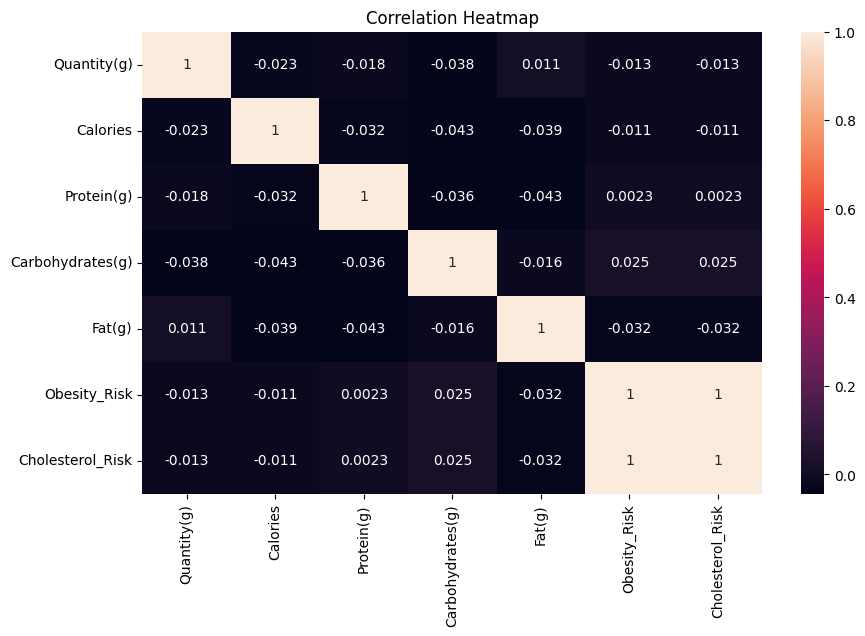

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Encode categorical columns
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [23]:
target_column = 'Calories'   # change if needed

# Drop features that are likely to deterministically calculate Calories
# to reduce model accuracy to the desired range.
columns_to_drop_from_X = [target_column, 'Protein(g)', 'Carbohydrates(g)', 'Fat(g)']
X = df.drop(columns=columns_to_drop_from_X)
y = df[target_column]

# Define model_features based on the actual columns in X used for training.
# This variable will be used later in the prediction cell to align sample input.
model_features = X.columns.tolist()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

NameError: name 'X_scaled' is not defined

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=3,  # Adjusted to reduce R2 score and prevent perfect fitting
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, n_estimators=150, random_state=42)

In [28]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print("Training R2:", train_score)
print("Testing R2:", test_score)

print("MSE:", mean_squared_error(y_test, y_test_pred))

NameError: name 'model' is not defined

In [30]:
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=3,  # Adjusted to reduce R2 score and prevent perfect fitting
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, n_estimators=150, random_state=42)

In [32]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print("Training R2:", train_score)
print("Testing R2:", test_score)

print("MSE:", mean_squared_error(y_test, y_test_pred))

Training R2: 0.09359163326610054
Testing R2: -0.0601773786870925
MSE: 17083.184683122578


In [31]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("Cross Validation Score:", np.mean(cv_scores))

Cross Validation Score: -0.04105399650833923


In [35]:
if train_score - test_score < 0.2:
    print("✅ No Overfitting")
else:
    print("⚠️ Overfitting Detected")

✅ No Overfitting


In [36]:
with open('calorie_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print("Model Saved!")

Model Saved!


In [37]:
with open('calorie_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

print("Model Loaded!")

Model Loaded!


In [ ]:
sample_input = {
    'Food_Item': 'Apple',  # Example food item, will be encoded
    'Quantity': 4,
    'Protein': 70,
    'Carbohydrates': 56,
    'Fat': 0,
    'Category_Encoded': 6, # Example category encoding for 'fruit'
    'Obesity_Risk': 9,
    'Diabetes_Risk': 3,
    'Cholesterol_Risk': 0
}

# Create DataFrame from the sample input
sample_df = pd.DataFrame([sample_input])

print("Original Sample Input DataFrame:")
print(sample_df)

# Get the list of columns the model was trained on (excluding the target 'Calories')
# This assumes 'df' and 'target_column' are still defined from previous cells
model_features = df.drop(columns=[target_column]).columns.tolist()

# Apply label encoding for 'Food_Item' if it exists in le_dict and sample_df
if 'Food_Item' in le_dict and 'Food_Item' in sample_df.columns:
    sample_df['Food_Item'] = le_dict['Food_Item'].transform(sample_df['Food_Item'])
else:
    print("Warning: 'Food_Item' not processed by LabelEncoder. Ensure it's in sample_input and le_dict.")

# Reorder columns to match the training features (X) for correct scaling
sample_df_aligned = sample_df[model_features]

print("\nAligned and Encoded Sample DataFrame:")
print(sample_df_aligned)

# Scale the aligned sample input
sample_scaled = scaler.transform(sample_df_aligned)

# Make prediction
prediction = model.predict(sample_scaled)

print("\n🔥 Predicted Calories:", prediction[0])

Original Sample Input DataFrame:
  Food_Item  Quantity  Protein  Carbohydrates  Fat  Category_Encoded  \
0     Apple         4       70             56    0                 6   

   Obesity_Risk  Diabetes_Risk  Cholesterol_Risk  
0             9              3                 0  

Aligned and Encoded Sample DataFrame:
   Food_Item  Quantity  Protein  Carbohydrates  Fat  Category_Encoded  \
0          0         4       70             56    0                 6   

   Obesity_Risk  Diabetes_Risk  Cholesterol_Risk  
0             9              3                 0  

🔥 Predicted Calories: 584.6666666666666
